# Customer Segmentation - Data Exploration

This notebook explores the Online Retail II dataset before data cleaning and customer segmentation.

The main goals are to:

- understand the structure of the dataset
- check data types and missing values
- identify data quality issues
- examine customer, product, invoice, and country information
- validate basic business rules
- prepare an initial assessment for the next stage of the project


## 1. Setup


In [1]:
import sys
from pathlib import Path

sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.helpers import (
    load_data,
    get_dataframe_info,
    check_missing_values,
    get_duplicate_info,
    save_json,
    display_value_counts,
    get_numeric_summary
)

from src.data.validation import (
    validate_schema,
    identify_data_quality_issues,
    validate_date_range,
    check_referential_integrity,
    generate_validation_report
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

np.random.seed(42)


## 2. Load Dataset

The dataset is stored in the project's `data/raw` directory.


In [2]:
data_path = Path('../data/raw/online_retail_II.xlsx')

if not data_path.exists():
    raise FileNotFoundError(
        'Dataset not found. Expected: data/raw/online_retail_II.xlsx'
    )

df = load_data(
    str(data_path),
    sheet_name='Year 2009-2010'
)

if df is None:
    raise ValueError('The dataset could not be loaded.')

df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice',
    'Customer ID': 'CustomerID'
})

print(f'Dataset shape: {df.shape}')
display(df.head())


Loading dataset from: ..\data\raw\online_retail_II.xlsx
Sheet: Year 2009-2010

✓ Dataset loaded successfully!
  Shape: 525,461 rows × 8 columns
  Memory: 122.87 MB

Dataset shape: (525461, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


## 3. Initial Data Inspection

A quick inspection helps confirm that the dataset has loaded correctly and gives an initial view of the transactions.


In [3]:
display(df.head(10))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.00,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.00,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.00,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.00,United Kingdom


In [4]:
display(df.tail())


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.00,United Kingdom


In [5]:
display(df.sample(5, random_state=42))


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
391453,527050,20750,RED RETROSPOT MINI CASES,6,2010-10-14 12:54:00,7.95,17717.00,United Kingdom
440086,531382,82583,HOT BATHS METAL SIGN,3,2010-11-07 16:29:00,2.10,16549.00,United Kingdom
369036,525059,22951,72 CAKE CASES DOLLY GIRL DESIGN,48,2010-10-03 14:08:00,0.55,15978.00,United Kingdom
232578,511928,21915,RED HARMONICA IN BOX,12,2010-06-11 11:45:00,1.25,15141.00,United Kingdom
41357,492792,22311,OFFICE MUG WARMER BLACK+SILVER,12,2009-12-20 10:08:00,4.95,17243.00,United Kingdom


## 4. Dataset Structure

This section checks the dimensions, column names, data types, missing values, duplicates, and memory usage.


In [6]:
print('Shape:', df.shape)

print('\nColumns:')
print(df.columns.tolist())

print('\nData types:')
display(df.dtypes.to_frame('Data Type'))


Shape: (525461, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,Data Type
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str


In [7]:
info = get_dataframe_info(df)

summary = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Total Cells',
        'Memory Usage (MB)',
        'Duplicate Rows',
        'Missing Values',
        'Missing Percentage'
    ],
    'Value': [
        f"{info['n_rows']:,}",
        info['n_columns'],
        f"{info['n_rows'] * info['n_columns']:,}",
        info['memory_mb'],
        f"{info['duplicates']:,}",
        f"{info['total_missing']:,}",
        f"{info['missing_percentage']}%"
    ]
})

display(summary)


,Metric,Value
0,Rows,"525,461"
1,Columns,8
2,Total Cells,"4,203,688"
3,Memory Usage (MB),122.87
4,Duplicate Rows,"6,865"
5,Missing Values,"110,855"
6,Missing Percentage,2.64%


## 5. Schema Validation

The dataset is expected to contain eight columns representing invoices, products, quantities, dates, prices, customers, and countries.


In [8]:
expected_cols = [
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'CustomerID',
    'Country'
]

is_valid, issues = validate_schema(df)

print('Schema valid:', is_valid)

if issues:
    print('\nIssues:')
    for issue in issues:
        print('-', issue)

print('\nExpected columns:')
print(expected_cols)

print('\nActual columns:')
print(df.columns.tolist())


Schema valid: True

Expected columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Actual columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 6. Missing Values

Missing values can affect customer-level analysis, especially when customer IDs are unavailable.


In [9]:
missing_df = check_missing_values(df)

display(missing_df)


,Column,Missing_Count,Missing_Percentage
6,CustomerID,107927,20.54
2,Description,2928,0.56


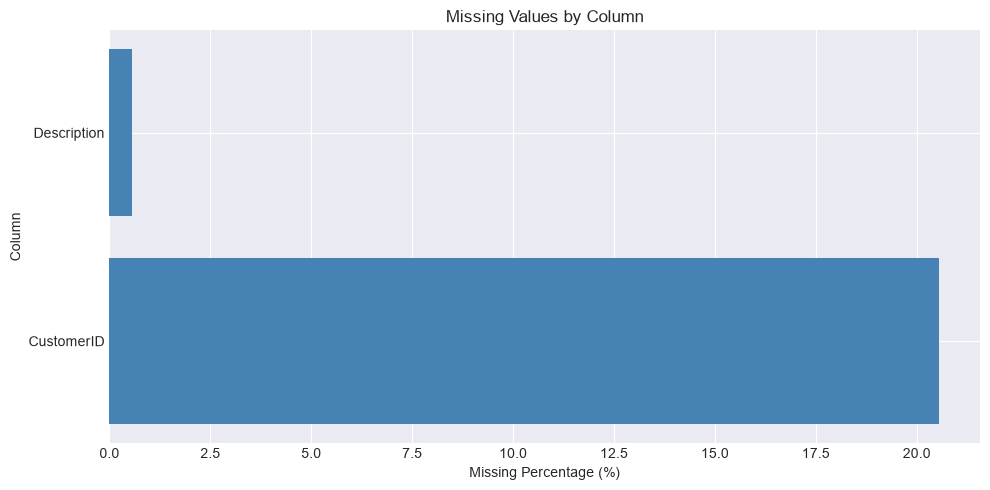

In [10]:
if not missing_df.empty:
    plt.figure(figsize=(10, 5))

    plt.barh(
        missing_df['Column'],
        missing_df['Missing_Percentage'],
        color='steelblue'
    )

    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Column')
    plt.title('Missing Values by Column')

    plt.tight_layout()
    plt.show()


The missing-value results will be considered during the data-cleaning stage. Customer ID is particularly important because the segmentation analysis will be performed at the customer level.


## 7. Data Quality Assessment

This section checks for common problems such as invalid values, missing information, duplicates, and unusual transactions.


In [11]:
issues_dict = identify_data_quality_issues(
    df,
    verbose=True
)

issue_summary = pd.DataFrame([
    {
        'Issue': name.replace('_', ' ').title(),
        'Count': data['count'],
        'Percentage': data['percentage'],
        'Severity': data.get('severity', 'INFO')
    }
    for name, data in issues_dict.items()
])

issue_summary = issue_summary.sort_values(
    'Percentage',
    ascending=False
)

display(issue_summary)


DATA QUALITY ISSUES IDENTIFIED

🔴 Missing Customer Id
   Count: 107,927
   Percentage: 20.54%
   Severity: HIGH

🟡 Cancelled Transactions
   Count: 10,206
   Percentage: 1.94%
   Severity: MEDIUM

🟡 Negative Quantities
   Count: 12,326
   Percentage: 2.35%
   Severity: MEDIUM
   Note: Likely represents returns or corrections

🟢 Zero Quantities
   Count: 0
   Percentage: 0.0%
   Severity: LOW

🔴 Invalid Prices
   Count: 3,690
   Percentage: 0.7%
   Severity: HIGH

🟢 Missing Descriptions
   Count: 2,928
   Percentage: 0.56%
   Severity: LOW

🟡 Duplicate Records
   Count: 6,865
   Percentage: 1.31%
   Severity: MEDIUM

ℹ️ Total Missing Values
   Count: 110,855
   Percentage: 2.64%
   Severity: INFO




,Issue,Count,Percentage,Severity
0,Missing Customer Id,107927,20.54,HIGH
7,Total Missing Values,110855,2.64,INFO
2,Negative Quantities,12326,2.35,MEDIUM
1,Cancelled Transactions,10206,1.94,MEDIUM
6,Duplicate Records,6865,1.31,MEDIUM
4,Invalid Prices,3690,0.70,HIGH
5,Missing Descriptions,2928,0.56,LOW
3,Zero Quantities,0,0.00,LOW


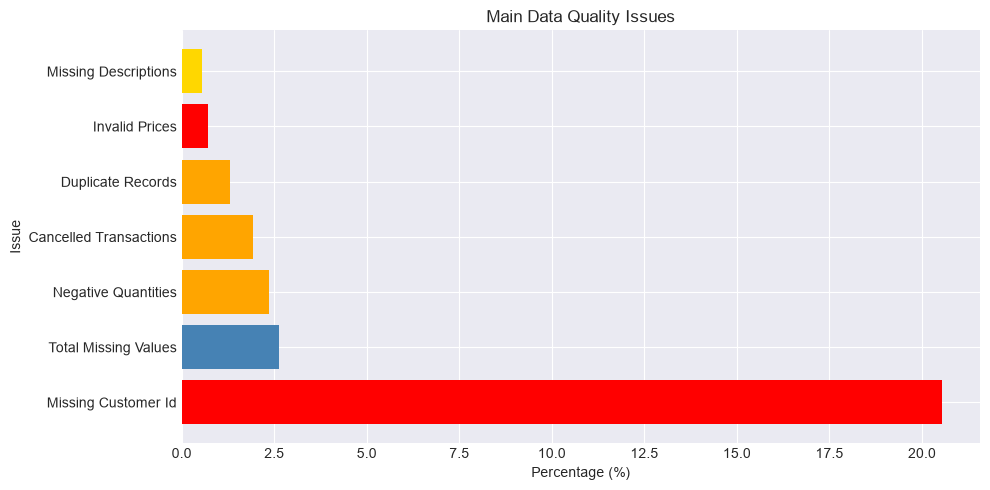

In [12]:
top_issues = issue_summary.nlargest(7, 'Percentage')

severity_colors = {
    'HIGH': 'red',
    'MEDIUM': 'orange',
    'LOW': 'gold',
    'INFO': 'steelblue'
}

colors = [
    severity_colors.get(x, 'gray')
    for x in top_issues['Severity']
]

plt.figure(figsize=(10, 5))

plt.barh(
    top_issues['Issue'],
    top_issues['Percentage'],
    color=colors
)

plt.xlabel('Percentage (%)')
plt.ylabel('Issue')
plt.title('Main Data Quality Issues')

plt.tight_layout()
plt.show()


## 8. Descriptive Statistics


In [13]:
display(df.describe())


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845018,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [14]:
numeric_summary = get_numeric_summary(df)

display(numeric_summary)


,count,missing,missing_pct,mean,std,min,25%,50%,75%,max,zeros,negatives
Quantity,525461.00,0,0.00,10.34,107.42,-9600.00,1.00,3.00,10.00,19152.00,0,12326
UnitPrice,525461.00,0,0.00,4.69,146.13,-53594.36,1.25,2.10,4.21,25111.09,3687,3
CustomerID,417534.00,107927,20.54,15360.65,1680.81,12346.00,13983.00,15311.00,16799.00,18287.00,0,0


## 9. Categorical Variables

The main categorical variables are examined using their most frequent values.


In [15]:
categorical_cols = df.select_dtypes(
    include=['object']
).columns

for col in categorical_cols:
    print(f'\n{col}')
    display(
        display_value_counts(
            df,
            col,
            top_n=10
        )
    )



InvoiceNo


,Value,Count,Percentage
0,537434,675,0.13
1,538071,652,0.12
2,537638,601,0.11
3,537237,597,0.11
4,536876,593,0.11
5,536592,592,0.11
6,537823,591,0.11
7,536031,582,0.11
8,490074,580,0.11
9,491966,579,0.11



StockCode


,Value,Count,Percentage
0,85123A,3516,0.67
1,22423,2221,0.42
2,85099B,2057,0.39
3,21212,1933,0.37
4,21232,1843,0.35
5,20725,1620,0.31
6,84879,1458,0.28
7,84991,1400,0.27
8,21754,1386,0.26
9,20914,1276,0.24



Description


,Value,Count,Percentage
0,WHITE HANGING HEART T-LIGHT HOLDER,3549,0.68
1,REGENCY CAKESTAND 3 TIER,2212,0.42
2,STRAWBERRY CERAMIC TRINKET BOX,1843,0.35
3,PACK OF 72 RETRO SPOT CAKE CASES,1466,0.28
4,ASSORTED COLOUR BIRD ORNAMENT,1457,0.28
5,60 TEATIME FAIRY CAKE CASES,1400,0.27
6,HOME BUILDING BLOCK WORD,1386,0.26
7,JUMBO BAG RED RETROSPOT,1310,0.25
8,LUNCH BAG RED SPOTTY,1274,0.24
9,REX CASH+CARRY JUMBO SHOPPER,1232,0.23



Country


,Value,Count,Percentage
0,United Kingdom,485852,92.46
1,EIRE,9670,1.84
2,Germany,8129,1.55
3,France,5772,1.10
4,Netherlands,2769,0.53
5,Spain,1278,0.24
6,Switzerland,1187,0.23
7,Portugal,1101,0.21
8,Belgium,1054,0.20
9,Channel Islands,906,0.17


## 10. Business-Level Validation

The following checks examine transaction dates, prices, quantities, invoices, customers, products, and countries.


In [16]:
date_info = validate_date_range(df)

print('Earliest transaction:', date_info['min_date'])
print('Latest transaction:', date_info['max_date'])
print('Date range:', date_info['range_days'], 'days')
print('Date range:', date_info['range_months'], 'months')


Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2010-12-09 20:01:00
Date range: 373 days
Date range: 12.4 months


In [17]:
negative_prices = (df['UnitPrice'] < 0).sum()
zero_prices = (df['UnitPrice'] == 0).sum()

price_summary = pd.DataFrame({
    'Metric': [
        'Minimum',
        'Maximum',
        'Mean',
        'Median',
        'Negative prices',
        'Zero prices'
    ],
    'Value': [
        df['UnitPrice'].min(),
        df['UnitPrice'].max(),
        df['UnitPrice'].mean(),
        df['UnitPrice'].median(),
        negative_prices,
        zero_prices
    ]
})

display(price_summary)


,Metric,Value
0,Minimum,-53594.36
1,Maximum,25111.09
2,Mean,4.69
3,Median,2.10
4,Negative prices,3.00
5,Zero prices,3687.00


In [18]:
negative_qty = (df['Quantity'] < 0).sum()
zero_qty = (df['Quantity'] == 0).sum()

quantity_summary = pd.DataFrame({
    'Metric': [
        'Minimum',
        'Maximum',
        'Mean',
        'Median',
        'Negative quantities',
        'Zero quantities'
    ],
    'Value': [
        df['Quantity'].min(),
        df['Quantity'].max(),
        df['Quantity'].mean(),
        df['Quantity'].median(),
        negative_qty,
        zero_qty
    ]
})

display(quantity_summary)



,Metric,Value
0,Minimum,-9600.00
1,Maximum,19152.00
2,Mean,10.34
3,Median,3.00
4,Negative quantities,12326.00
5,Zero quantities,0.00


In [19]:
total_invoices = df['InvoiceNo'].nunique()

cancelled_invoices = df[
    df['InvoiceNo'].astype(str).str.startswith(
        'C',
        na=False
    )
]['InvoiceNo'].nunique()

invoice_summary = pd.DataFrame({
    'Metric': [
        'Unique invoices',
        'Cancelled invoices',
        'Regular invoices'
    ],
    'Value': [
        total_invoices,
        cancelled_invoices,
        total_invoices - cancelled_invoices
    ]
})

display(invoice_summary)


,Metric,Value
0,Unique invoices,28816
1,Cancelled invoices,4592
2,Regular invoices,24224


In [20]:
customer_summary = pd.DataFrame({
    'Metric': [
        'Unique customers',
        'Transactions with customer ID',
        'Transactions without customer ID'
    ],
    'Value': [
        df['CustomerID'].nunique(),
        df['CustomerID'].notna().sum(),
        df['CustomerID'].isna().sum()
    ]
})

display(customer_summary)


,Metric,Value
0,Unique customers,4383
1,Transactions with customer ID,417534
2,Transactions without customer ID,107927


In [21]:
product_summary = pd.DataFrame({
    'Metric': [
        'Unique products',
        'Rows with description',
        'Rows without description'
    ],
    'Value': [
        df['StockCode'].nunique(),
        df['Description'].notna().sum(),
        df['Description'].isna().sum()
    ]
})

display(product_summary)


,Metric,Value
0,Unique products,4632
1,Rows with description,522533
2,Rows without description,2928


In [22]:
country_dist = display_value_counts(
    df,
    'Country',
    top_n=10
)

display(country_dist)


,Value,Count,Percentage
0,United Kingdom,485852,92.46
1,EIRE,9670,1.84
2,Germany,8129,1.55
3,France,5772,1.10
4,Netherlands,2769,0.53
5,Spain,1278,0.24
6,Switzerland,1187,0.23
7,Portugal,1101,0.21
8,Belgium,1054,0.20
9,Channel Islands,906,0.17


## 11. Referential Integrity

These checks look for relationships between fields that could cause problems during later analysis.


In [23]:
integrity_results = check_referential_integrity(df)

for check_name, check_data in integrity_results.items():

    print(check_name.replace('_', ' ').title())

    for key, value in check_data.items():
        print(f'{key}: {value}')

    print()


Invoice Customer Relationship
total_invoices: 28816
multi_customer_invoices: 0
is_valid: True

Stockcode Description Relationship
total_products: 4632
products_with_multiple_descriptions: 687
is_consistent: False



## 12. Duplicate Records


In [24]:
dup_info = get_duplicate_info(df)

print('Duplicate rows:', f"{dup_info['count']:,}")
print('Percentage:', f"{dup_info['percentage']}%")

if dup_info['count'] > 0:
    display(
        dup_info['duplicate_rows'].head(10)
    )


Duplicate rows: 6,865
Percentage: 1.31%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom


## 13. Validation Report

The validation results are saved in the project's `reports` directory for use in later stages of the project.


In [25]:
reports_path = Path('../reports')
reports_path.mkdir(exist_ok=True)

report = generate_validation_report(
    df,
    save_path=str(
        reports_path / 'validation_report.json'
    )
)

print('Validation report saved.')


✓ Validation report saved to: ..\reports\validation_report.json
Validation report saved.


In [26]:
initial_assessment = {
    'dataset_name': 'Online Retail II (2009-2010)',
    'analysis_date': pd.Timestamp.now().isoformat(),
    'total_records': len(df),
    'total_columns': len(df.columns),

    'date_range': {
        'start': str(df['InvoiceDate'].min()),
        'end': str(df['InvoiceDate'].max()),
        'days': int(
            (
                df['InvoiceDate'].max()
                - df['InvoiceDate'].min()
            ).days
        )
    },

    'unique_counts': {
        'customers': int(df['CustomerID'].nunique()),
        'products': int(df['StockCode'].nunique()),
        'invoices': int(df['InvoiceNo'].nunique()),
        'countries': int(df['Country'].nunique())
    },

    'data_quality': {
        'missing_customer_id': int(
            df['CustomerID'].isnull().sum()
        ),
        'negative_quantities': int(
            (df['Quantity'] < 0).sum()
        ),
        'invalid_prices': int(
            (df['UnitPrice'] <= 0).sum()
        ),
        'duplicates': int(
            df.duplicated().sum()
        )
    }
}

save_json(
    initial_assessment,
    str(
        reports_path / 'initial_assessment.json'
    )
)

print('Initial assessment saved.')


✓ JSON saved to: ..\reports\initial_assessment.json
Initial assessment saved.


## 14. Key Findings

The initial exploration gives an overview of the dataset and highlights issues that should be addressed before customer segmentation.

### Dataset

- The dataset contains transactions from the 2009-2010 period.
- Customer, product, invoice, and country information are available.
- The dataset contains both positive and negative quantities, which require further investigation.

### Data Quality

- Customer IDs are missing for some transactions.
- Duplicate records should be checked before building customer-level features.
- Non-positive prices need to be investigated.
- Negative quantities may represent returns or other transaction adjustments.

### Next Steps

The next stage will focus on cleaning the transaction data, handling missing customer information, creating revenue-related features, and preparing the data for RFM analysis and customer segmentation.
